# Chapter 1: What Breaks After You Ship

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/hardening-llm-systems-production/blob/main/companion-code/ch01-what-breaks-after-you-ship/ch01_notebook.ipynb)
## Hardening LLM Systems in Production
**Author:** Rudrendu Paul | https://orcid.org/0009-0008-0141-4690

---

### What this notebook builds

This notebook walks through the **HardeningReport** self-diagnostic scorecard introduced in Chapter 1.
The scorecard asks 25 yes/no questions across five hardening vectors and produces:

- An overall **readiness band** (HARDENED / REINFORCED / EXPOSED / VULNERABLE)
- A per-vector **risk level** (LOW / MEDIUM / HIGH / CRITICAL)
- A **prioritized remediation plan** ordered by most dangerous gaps first

Run this notebook against any LLM-powered system before its first production deployment,
and again after every major model update.

### The five hardening vectors

| Vector | Questions | What it catches |
|--------|-----------|------------------|
| Hallucination & Factuality | H1–H5 | Missing automated faithfulness checks, no regression suite |
| Prompt Injection & Adversarial Inputs | P1–P5 | Unsanitized user input, overly permissive tool grants |
| Output Safety & Policy Compliance | O1–O5 | No safety classifier, PII leakage risk, missing circuit-breaker |
| Observability & Incident Response | I1–I5 | Unstructured logs, no runbook, no shadow traffic |
| Governance & Access Control | G1–G5 | No model registry, no model card, unreviewed prompt changes |

## Manuscript reference

This notebook demonstrates the concepts from Chapter 1 of *Hardening LLM Systems in Production* (Manning, 2026).

| Notebook section | Manuscript listing | Class / function |
|------------------|--------------------|------------------|
| LLM stack scanning | Listing 1.1 | `scan_llm_stack` |
| Incident tagging | Listing 1.2 | `tag_incident` |
| Incident classification | Listing 1.3 | `classify_incident` |
| Exposure map generation | Listing 1.4 | `generate_exposure_map` |
| Hardening scorecard | Listing 1.5 | `HardeningReport` |
| Readiness report | Listing 1.6 | `HardeningReadinessReport` |


In [1]:
# ── Colab setup ────────────────────────────────────────────────────────────
# This cell only runs when executed in Google Colab.
# Local Jupyter users: skip — all code is stdlib or pip-installable.
import sys, os

if 'google.colab' in sys.modules:
    !git clone -q https://github.com/RudrenduPaul/hardening-llm-systems-production.git
    os.chdir('hardening-llm-systems-production/companion-code/ch01-what-breaks-after-you-ship')
    print('Colab setup complete — repo cloned, packages installed.')


In [ ]:
# Install pinned dependencies (run once per environment)
# Uncomment and run in Colab or a fresh virtual environment:
# !pip install requests>=2.32.0,<3.0 pydantic>=2.7.0,<3.0 matplotlib>=3.9.0,<4.0


## Setup

The HardeningReport class uses only Python standard library modules.
No pip installs required for this chapter.

In [2]:
# Verify we are running Python 3.11+
import sys
print(f"Python {sys.version}")
assert sys.version_info >= (3, 11), "Python 3.11 or higher required"

# Import the companion script module
import importlib.util, pathlib

script_path = pathlib.Path("ch01_scripts.py")
spec = importlib.util.spec_from_file_location("ch01_scripts", script_path)
ch01 = importlib.util.module_from_spec(spec)
sys.modules['ch01_scripts'] = ch01  # required for Python 3.14
spec.loader.exec_module(ch01)

print("ch01_scripts loaded successfully.")
print(f"Diagnostic questions: {len(ch01.DIAGNOSTIC_QUESTIONS)}")
print(f"Hardening vectors   : {ch01.HARDENING_VECTORS}")

Python 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]


ch01_scripts loaded successfully.
Diagnostic questions: 25
Hardening vectors   : ['Hallucination & Factuality', 'Prompt Injection & Adversarial Inputs', 'Output Safety & Policy Compliance', 'Observability & Incident Response', 'Governance & Access Control']


## Section 1: The HardeningReport class

The `HardeningReport` class is the core artifact of Chapter 1.
It holds your yes/no answers and computes scores per vector and overall.

In [3]:
# Inspect the 25 questions
for i, q in enumerate(ch01.DIAGNOSTIC_QUESTIONS, 1):
    print(f"  [{q['id']}] {q['vector'][:30]:<30} {q['question'][:70]}")

  [H1] Hallucination & Factuality     Do you run an automated faithfulness metric (e.g. RAGAS, deepeval) on 
  [H2] Hallucination & Factuality     Do you track hallucination rate as a production KPI on a dashboard?
  [H3] Hallucination & Factuality     Do you run self-consistency checks (sample N responses, compare) for h
  [H4] Hallucination & Factuality     Do you decompose compound claims into atomic assertions before scoring
  [H5] Hallucination & Factuality     Do you maintain a regression test suite of known hallucination cases?
  [P1] Prompt Injection & Adversarial Do you scan user inputs for direct prompt injection patterns before th
  [P2] Prompt Injection & Adversarial Do you sanitize or constrain tool-call arguments returned by the model
  [P3] Prompt Injection & Adversarial Do you apply structural separation between system instructions and use
  [P4] Prompt Injection & Adversarial Do you red-team your prompts quarterly for jailbreak and indirect inje
  [P5] Prompt Injection

## Section 2: Running the scorecard on a demo system

Three demo scenarios are pre-built to show the full output range.
The **mixed** scenario represents a realistic early-production LLM system:
some controls exist (a CI metric, a safety classifier, structured logs),
but critical gaps remain (no PII scanner, no runbook, no model registry).

In [4]:
# --- Scenario A: Mixed (realistic early-production system) ---
report_mixed = ch01.demo_report(scenario="mixed")
print(report_mixed.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Acme Customer Support Bot v2.1
  Assessor: Rudrendu Paul
  Date    : 2026-05-31

  OVERALL SCORE : 40% (25/25 questions answered)
  READINESS BAND: EXPOSED

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  [HIGH] Hallucination & Factuality               [########------------]  40%  [HIGH]
  [HIGH] Prompt Injection & Adversarial Inputs    [########------------]  40%  [HIGH]
  [WARN] Output Safety & Policy Compliance        [############--------]  60%  [MEDIUM]
  [HIGH] Observability & Incident Response        [########------------]  40%  [HIGH]
  [CRIT] Governance & Access Control              [####----------------]  20%  [CRITICAL]

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector risk, highest first)
---------------------------------------------------

In [5]:
# --- Scenario B: Worst case (no controls at all) ---
report_worst = ch01.demo_report(scenario="worst")
print(report_worst.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Acme Customer Support Bot v2.1
  Assessor: Rudrendu Paul
  Date    : 2026-05-31

  OVERALL SCORE : 0% (25/25 questions answered)
  READINESS BAND: VULNERABLE

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  [CRIT] Hallucination & Factuality               [--------------------]   0%  [CRITICAL]
  [CRIT] Prompt Injection & Adversarial Inputs    [--------------------]   0%  [CRITICAL]
  [CRIT] Output Safety & Policy Compliance        [--------------------]   0%  [CRITICAL]
  [CRIT] Observability & Incident Response        [--------------------]   0%  [CRITICAL]
  [CRIT] Governance & Access Control              [--------------------]   0%  [CRITICAL]

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector risk, highest first)
-----------------------------------

In [6]:
# --- Scenario C: Best case (all controls in place) ---
report_best = ch01.demo_report(scenario="best")
print(report_best.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Acme Customer Support Bot v2.1
  Assessor: Rudrendu Paul
  Date    : 2026-05-31

  OVERALL SCORE : 100% (25/25 questions answered)
  READINESS BAND: HARDENED

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  [OK] Hallucination & Factuality               [####################] 100%  [LOW]
  [OK] Prompt Injection & Adversarial Inputs    [####################] 100%  [LOW]
  [OK] Output Safety & Policy Compliance        [####################] 100%  [LOW]
  [OK] Observability & Incident Response        [####################] 100%  [LOW]
  [OK] Governance & Access Control              [####################] 100%  [LOW]

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector risk, highest first)
--------------------------------------------------------------------



## Section 3: Scoring your own system

Fill in your actual yes/no answers below.
Each question ID corresponds to a row in the scorecard.
Change `True`/`False` to reflect your real system state.

In [7]:
my_report = ch01.HardeningReport(
    system_name="Your System Name Here",
    assessor="Your Name",
)

# --- Hallucination & Factuality ---
my_report.answer("H1", False)   # CI faithfulness metric?
my_report.answer("H2", False)   # Production hallucination dashboard?
my_report.answer("H3", False)   # Self-consistency checks?
my_report.answer("H4", False)   # Claim decomposition?
my_report.answer("H5", False)   # Hallucination regression suite?

# --- Prompt Injection & Adversarial Inputs ---
my_report.answer("P1", False)   # Input injection scan?
my_report.answer("P2", False)   # Tool-arg validation?
my_report.answer("P3", False)   # Structural role separation?
my_report.answer("P4", False)   # Quarterly red-team?
my_report.answer("P5", False)   # Input anomaly monitoring?

# --- Output Safety & Policy Compliance ---
my_report.answer("O1", False)   # Policy classifier on outputs?
my_report.answer("O2", False)   # Documented fallback responses?
my_report.answer("O3", False)   # PII scan on outputs?
my_report.answer("O4", False)   # Violation log for audit?
my_report.answer("O5", False)   # Circuit-breaker on violation spike?

# --- Observability & Incident Response ---
my_report.answer("I1", False)   # Structured logs for every LLM call?
my_report.answer("I2", False)   # Incident runbook?
my_report.answer("I3", False)   # Latency p50/p95/p99 alerts?
my_report.answer("I4", False)   # Shadow traffic for new models?
my_report.answer("I5", False)   # Tested rollback procedure (<15 min)?

# --- Governance & Access Control ---
my_report.answer("G1", False)   # Model registry?
my_report.answer("G2", False)   # Least-privilege tool grants?
my_report.answer("G3", False)   # Model cards for all production models?
my_report.answer("G4", False)   # PR-gated prompt changes?
my_report.answer("G5", False)   # Named AI risk owner?

print(my_report.summary())

  HARDENING REPORT: LLM System Self-Diagnostic
  System  : Your System Name Here
  Assessor: Your Name
  Date    : 2026-05-31

  OVERALL SCORE : 0% (25/25 questions answered)
  READINESS BAND: VULNERABLE

--------------------------------------------------------------------
  VECTOR SCORES
--------------------------------------------------------------------
  [CRIT] Hallucination & Factuality               [--------------------]   0%  [CRITICAL]
  [CRIT] Prompt Injection & Adversarial Inputs    [--------------------]   0%  [CRITICAL]
  [CRIT] Output Safety & Policy Compliance        [--------------------]   0%  [CRITICAL]
  [CRIT] Observability & Incident Response        [--------------------]   0%  [CRITICAL]
  [CRIT] Governance & Access Control              [--------------------]   0%  [CRITICAL]

--------------------------------------------------------------------
  PRIORITIZED REMEDIATION PLAN
  (ordered by vector risk, highest first)
------------------------------------------------

## Section 4: Understanding the readiness bands

| Band | Overall score | What it means |
|------|--------------|----------------|
| HARDENED | 80%+ | complete controls in place. Focus on continuous improvement. |
| REINFORCED | 60–79% | Core safety controls exist. Fix remaining gaps before next scale event. |
| EXPOSED | 40–59% | Significant gaps. A single adversarial user or model update can cause incidents. |
| VULNERABLE | <40% | Systemic hardening debt. Ship no new traffic until critical gaps are closed. |

In [8]:
# Compare readiness bands across the three demo scenarios
for scenario in ["worst", "mixed", "best"]:
    r = ch01.demo_report(scenario)
    print(f"  {scenario:<8} → score={r.total_score_pct:>3}%  band={r.readiness_band}")

  worst    → score=  0%  band=VULNERABLE
  mixed    → score= 40%  band=EXPOSED
  best     → score=100%  band=HARDENED


## Section 5: Visualizing vector scores

A quick bar chart showing per-vector scores across the mixed scenario.
This is the visualization you would embed in an executive dashboard.

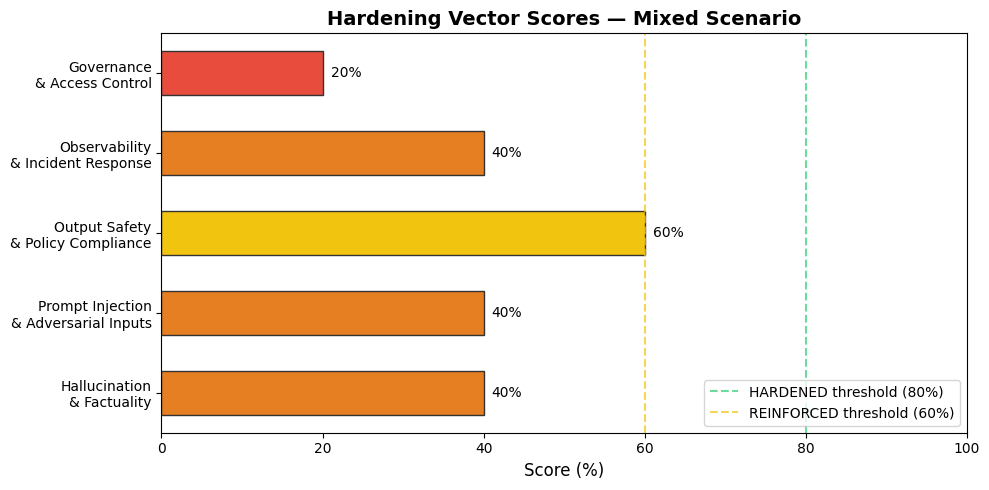

Chart saved to ch01_vector_scores.png


In [9]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    report = ch01.demo_report("mixed")
    vector_scores = report._compute_vector_scores()

    labels = [vs.name.replace(" & ", "\n& ") for vs in vector_scores.values()]
    scores = [vs.score_pct for vs in vector_scores.values()]
    colors = [
        "#2ecc71" if s >= 80 else
        "#f1c40f" if s >= 60 else
        "#e67e22" if s >= 40 else
        "#e74c3c"
        for s in scores
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels, scores, color=colors, height=0.55, edgecolor="#333")
    ax.axvline(x=80, linestyle="--", color="#2ecc71", alpha=0.7, label="HARDENED threshold (80%)")
    ax.axvline(x=60, linestyle="--", color="#f1c40f", alpha=0.7, label="REINFORCED threshold (60%)")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Score (%)", fontsize=12)
    ax.set_title("Hardening Vector Scores — Mixed Scenario", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")

    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f"{score}%", va="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("ch01_vector_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to ch01_vector_scores.png")

except ImportError:
    print("matplotlib not installed — skipping chart. pip install matplotlib to enable.")

## Section 6: Exporting the report to JSON

The JSON export is the format used to feed the scorecard into
automated governance dashboards, JIRA ticket generators, or Slack alerts.

In [10]:
import json

report = ch01.demo_report("mixed")
report_dict = report.to_dict()

print(json.dumps(report_dict, indent=2))

{
  "system_name": "Acme Customer Support Bot v2.1",
  "assessor": "Rudrendu Paul",
  "date": "2026-05-31",
  "overall_score_pct": 40,
  "readiness_band": "EXPOSED",
  "answered_questions": 25,
  "total_questions": 25,
  "vectors": [
    {
      "name": "Hallucination & Factuality",
      "score_pct": 40,
      "risk_level": "HIGH",
      "answered_yes": 2,
      "total": 5,
      "gaps": [
        "H2",
        "H3",
        "H4"
      ]
    },
    {
      "name": "Prompt Injection & Adversarial Inputs",
      "score_pct": 40,
      "risk_level": "HIGH",
      "answered_yes": 2,
      "total": 5,
      "gaps": [
        "P2",
        "P4",
        "P5"
      ]
    },
    {
      "name": "Output Safety & Policy Compliance",
      "score_pct": 60,
      "risk_level": "MEDIUM",
      "answered_yes": 3,
      "total": 5,
      "gaps": [
        "O3",
        "O5"
      ]
    },
    {
      "name": "Observability & Incident Response",
      "score_pct": 40,
      "risk_level": "HIGH",
    

In [11]:
# Save to disk
report.export_json("ch01_hardening_report.json")
print("Report saved to ch01_hardening_report.json")

Report saved to ch01_hardening_report.json
Report saved to ch01_hardening_report.json


## Section 7: Tracking score over time

The scorecard is most useful when run repeatedly, before launch, after each
major model update, and after each incident. Tracking it over time shows
whether hardening debt is accumulating or being repaid.

In [12]:
# Simulate a time series of scorecard runs
# In practice, load these from saved JSON exports

snapshots = [
    {"date": "2025-01-01", "score": 28, "band": "VULNERABLE"},
    {"date": "2025-03-01", "score": 44, "band": "EXPOSED"},
    {"date": "2025-06-01", "score": 60, "band": "REINFORCED"},
    {"date": "2025-09-01", "score": 72, "band": "REINFORCED"},
    {"date": "2026-01-01", "score": 84, "band": "HARDENED"},
]

print("Hardening Progress Over Time")
print("-" * 45)
for s in snapshots:
    bar = ch01._progress_bar(s["score"] / 100, width=25)
    print(f"  {s['date']}  {bar}  {s['score']:>3}%  [{s['band']}]")

Hardening Progress Over Time
---------------------------------------------
  2025-01-01  [#######------------------]   28%  [VULNERABLE]
  2025-03-01  [###########--------------]   44%  [EXPOSED]
  2025-06-01  [###############----------]   60%  [REINFORCED]
  2025-09-01  [##################-------]   72%  [REINFORCED]
  2026-01-01  [#####################----]   84%  [HARDENED]


## Summary

This notebook built the full **HardeningReport** self-diagnostic workflow.

### What you built
- A 25-question scorecard across 5 hardening vectors
- Per-vector risk ratings (LOW / MEDIUM / HIGH / CRITICAL)
- A prioritized remediation plan ordered by most dangerous gaps first
- JSON export for integration with governance dashboards

### Next steps
1. **Chapter 2**, Run `HallucinationMetric` from deepeval and RAGAS faithfulness scoring to close the H1 gap.
2. **Chapter 3**, Wire the hallucination gate into your GitHub Actions CI pipeline to close H1 systematically.
3. **Chapter 4**, Add prompt injection defense to close P1–P3.
4. **Chapter 5**, Secure your RAG retrieval layer to address O3 (PII leakage).
5. Re-run this scorecard after each chapter's implementation to track your readiness band improving.